<font size = "3">

**(Q1)** Below is the `build_parse_tree` function we saw in class, along with some  example calls to the function.

In [1]:
from assign4_utils import Stack, BinaryTree

def build_parse_tree(fp_expr):
    fp_list = fp_expr.split()
    p_stack = Stack()
    expr_tree = BinaryTree("")
    # p_stack.push(expr_tree)
    p_stack.push(None) # I think this is more clear
    current_tree = expr_tree

    for i in fp_list:
        if i == "(":
            current_tree.insert_left("")
            p_stack.push(current_tree)
            current_tree = current_tree.left_child
        elif i in ["+", "-", "*", "/"]:
            current_tree.key = i
            current_tree.insert_right("")
            p_stack.push(current_tree)
            current_tree = current_tree.right_child
        elif i.isdigit():
              current_tree.key = int(i)
              parent = p_stack.pop()
              current_tree = parent
        elif i == ")":
              current_tree = p_stack.pop()
        else:
              raise ValueError(f"Unknown operator '{i}'")

    return expr_tree

pt = build_parse_tree("( 10 + 3 )")
pt.postorder()

10
3
+


In [2]:
expr = "( ( ( 4 * 3 ) + ( 5 * 2 ) ) / 2 )"
pt = build_parse_tree(expr)
pt.postorder()

4
3
*
5
2
*
+
2
/


<font size = "3">

Modify the function to define `build_parse_tree_v2` which does not require the outermost parentheses in an expression.

In [3]:
def build_parse_tree_v2(fp_expr):
    return None 



---


In [4]:
from assign4_utils import Stack, BinaryTree

def build_parse_tree(fp_expr):
    fp_list = fp_expr.split()
    p_stack = Stack()
    expr_tree = BinaryTree("")
    p_stack.push(None)
    current_tree = expr_tree

    for i in fp_list:
        if i == "(":
            current_tree.insert_left("")
            p_stack.push(current_tree)
            current_tree = current_tree.left_child
        elif i in ["+", "-", "*", "/"]:
            current_tree.key = i
            current_tree.insert_right("")
            p_stack.push(current_tree)
            current_tree = current_tree.right_child
        elif i.isdigit():
            current_tree.key = int(i)
            parent = p_stack.pop()
            current_tree = parent
        elif i == ")":
            current_tree = p_stack.pop()
        else:
            raise ValueError(f"Unknown operator '{i}'")

    return expr_tree


def build_parse_tree_v2(fp_expr):
    # Wrap in outer parentheses so the original algorithm works
    # without requiring the user to supply them
    return build_parse_tree("( " + fp_expr + " )")



In [5]:
# This should return a tree with 
# the following values in a postorder traversal: 10 3 +
pt = build_parse_tree_v2("10 + 3")
pt.postorder()

10
3
+


In [13]:
# This should return a tree with 
# the following values in a postorder traversal: 4 3 * 5 2 * + 2 /
expr = "( ( 4 * 3 ) + ( 5 * 2 ) ) / 2"
pt = build_parse_tree_v2(expr)
pt.postorder()

4
3
*
5
2
*
+
2
/


<font size = "3">

**(Q2)** We can "invert" the procedure that converts a string into a parse tree using the `print_exp` function:

In [7]:
def print_exp(tree):
    result = ""
    if tree:
        result = "(" + print_exp(tree.left_child)
        result = result + str(tree.key)
        result = result + print_exp(tree.right_child) + ")"
    return result

pt = build_parse_tree("( ( 10 + 5 ) * 3 )")

pt_str = print_exp(pt)

print(pt_str)

(((10)+(5))*(3))


<font size = "3">

Modify the function so that it does not include the extra parentheses around each individual number.

I.e. the modified function would return the string `((10 + 5)*3)`

---
Check whether a node is a leaf. If it is, return just its value as a string with no parentheses. Only operator nodes (which have both a left and right child) get wrapped.


In [8]:
def print_exp_modified(tree):
    result = ""
    if tree:
        # Leaf node: just return the value, no parentheses
        if tree.left_child is None and tree.right_child is None:
            return str(tree.key)
        result = "(" + print_exp_modified(tree.left_child)
        result = result + str(tree.key)
        result = result + print_exp_modified(tree.right_child) + ")"
    return result


pt = build_parse_tree("( ( 10 + 5 ) * 3 )")
print(print_exp_modified(pt))  # Expected: ((10+5)*3)


((10+5)*3)


<font size = "3">

**(Q3)** Create a binary heap class with a limited heap size. In other words, the heap only keeps track of the $m$
most important items. If the heap grows in size to more than $m$ items the least important item is dropped (while maintaining the binary heap structure).

Continue to use the *min heap* framework, where the least important item has the largest key value.

---

1. Scan all leaf nodes to find the index of the maximum (least important).
2. Swap it with the last element and pop (just like `delete` does for the root).
3. Restore the heap property at that index by percolating up or down as needed.


In [9]:
class BinaryHeap:
    def __init__(self):
        self._heap = []

    def _perc_up(self, i):
        while (i - 1) // 2 >= 0:
            p = (i - 1) // 2
            if self._heap[i] < self._heap[p]:
                self._heap[i], self._heap[p] = self._heap[p], self._heap[i]
            else:
                break
            i = p

    def insert(self, item):
        self._heap.append(item)
        self._perc_up(len(self._heap) - 1)

    def _get_min_child(self, i):
        if 2 * i + 2 > len(self._heap) - 1:
            return 2 * i + 1
        if self._heap[2 * i + 1] < self._heap[2 * i + 2]:
            return 2 * i + 1
        return 2 * i + 2

    def _perc_down(self, i):
        while 2 * i + 1 < len(self._heap):
            sm_child = self._get_min_child(i)
            if self._heap[i] > self._heap[sm_child]:
                self._heap[i], self._heap[sm_child] = self._heap[sm_child], self._heap[i]
            else:
                break
            i = sm_child

    def delete(self):
        self._heap[0], self._heap[-1] = self._heap[-1], self._heap[0]
        result = self._heap.pop()
        self._perc_down(0)
        return result

    def heapify(self, not_a_heap):
        self._heap = not_a_heap[:]
        i = len(self._heap) // 2 - 1
        while i >= 0:
            self._perc_down(i)
            i -= 1

    def is_empty(self):
        return not bool(self._heap)

    def __len__(self):
        return len(self._heap)

    def __str__(self):
        return str(self._heap)


class LimitedBinaryHeap(BinaryHeap):
    def __init__(self, m):
        super().__init__()
        self.m = m  # maximum number of items to keep

    def _drop_least_important(self):
        """Remove the largest (least important) item from the heap.
        In a min heap the maximum is always a leaf node."""
        # Leaf nodes are at indices len//2 through len-1
        first_leaf = len(self._heap) // 2
        max_idx = first_leaf
        for i in range(first_leaf + 1, len(self._heap)):
            if self._heap[i] > self._heap[max_idx]:
                max_idx = i

        # Replace with last element and pop
        self._heap[max_idx] = self._heap[-1]
        self._heap.pop()

        # Restore heap property at max_idx
        if max_idx < len(self._heap):
            parent = (max_idx - 1) // 2
            if max_idx > 0 and self._heap[max_idx] < self._heap[parent]:
                self._perc_up(max_idx)
            else:
                self._perc_down(max_idx)

    def insert(self, item):
        super().insert(item)
        if len(self._heap) > self.m:
            self._drop_least_important()


In [14]:
# Test: keep only the 3 most important (smallest) items
lh = LimitedBinaryHeap(3)
for val in [10, 2, 7, 1, 5, 3]:
    lh.insert(val)
    print(f"Inserted {val}, heap: {lh}")

print("Deleting in priority order:")
while not lh.is_empty():
    print(lh.delete())


Inserted 10, heap: [10]
Inserted 2, heap: [2, 10]
Inserted 7, heap: [2, 10, 7]
Inserted 1, heap: [1, 2, 7]
Inserted 5, heap: [1, 2, 5]
Inserted 3, heap: [1, 2, 3]
Deleting in priority order:
1
2
3


<font size = "3">

**(Q4)** Using the `heapify` function, write a sorting function that can sort a sorted list in $\mathcal{O}(n\log n)$ time.

Keep the following in mind as you design your algorithm:

- The `heapify` method is an $\mathcal{O}(n)$ operation.

- "Percolating" up or down is an $\mathcal{O}(\log n)$ operation.

- Swapping two items in a list is an $\mathcal{O}(1)$ operation.

- Popping from the end of a list is an $\mathcal{O}(1)$ operation.

- Popping from the beginning of a list is an $\mathcal{O}(n)$ operation.

You might find it convenient to write an independent `heapify` function instead of calling the method from a `BinaryHeap` object.

---
- `heapify(lst)` rearranges `lst` into a valid min heap in $\mathcal{O}(n)$ time.
- `delete()` repeated $n$ times: each deletion swaps the root with the last element, pops from the end of the list ($\mathcal{O}(1)$), then percolates down ($\mathcal{O}(\log n)$). Total: $\mathcal{O}(n \log n)$.

We deliberately avoid `pop(0)` which would be $\mathcal{O}(n)$ per call and push the total to $\mathcal{O}(n^2)$.

Overall: $\mathcal{O}(n) + \mathcal{O}(n \log n) = \mathcal{O}(n \log n)$.


In [11]:
def heap_sort(lst):
    """Sort a list in ascending order using heapify. O(n log n)."""
    heap = BinaryHeap()
    heap.heapify(lst)          # O(n)
    sorted_lst = []
    while not heap.is_empty():
        sorted_lst.append(heap.delete())  # n * O(log n) = O(n log n)
    return sorted_lst


# Quick test
import random
test_list = random.sample(range(100), 10)
print("Original:", test_list)
print("Sorted:  ", heap_sort(test_list))


Original: [8, 33, 68, 69, 21, 59, 79, 55, 28, 17]
Sorted:   [8, 17, 21, 28, 33, 55, 59, 68, 69, 79]


<font size = "3">

**(Q5)** Empirically verify that the function you wrote for Question 4 has $\mathcal{O}(n \log n)$ cost by testing it on lists of integers of different sizes.

## Question 5

We empirically verify $\mathcal{O}(n \log n)$ cost following the timing approach from Lecture 20b. 

We time `heap_sort` on lists of increasing size using `default_timer` (to avoid issues with mutable state that arise with `timeit`). Then we plot the measured times against $C \cdot n \log n$ on a log-log scale — if the slope matches, the complexity is confirmed. We also plot the ratio $\text{time} / (n \log n)$: a flat line there is strong evidence of $\mathcal{O}(n \log n)$.


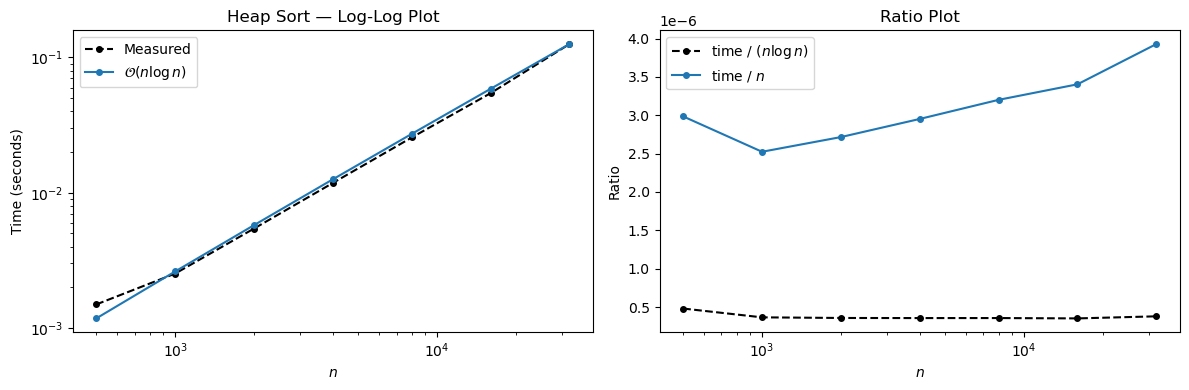

n values:     [500, 1000, 2000, 4000, 8000, 16000, 32000]
Avg times:    ['0.001493', '0.002525', '0.005432', '0.011810', '0.025614', '0.054469', '0.125731']


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import random
from timeit import default_timer

n_values = [500, 1000, 2000, 4000, 8000, 16000, 32000]
avg_times = []
num_repeats = 5

for n in n_values:
    total = 0
    for _ in range(num_repeats):
        lst = random.sample(range(n * 10), n)
        start = default_timer()
        heap_sort(lst)
        stop = default_timer()
        total += stop - start
    avg_times.append(total / num_repeats)

n_arr = np.array(n_values)
t_arr = np.array(avg_times)

# Scale C so the O(n log n) curve agrees with measured times at the largest n
nlogn = n_arr * np.log(n_arr)
C = t_arr[-1] / nlogn[-1]

# Log-log plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].loglog(n_arr, t_arr, 'k.--', label='Measured', markersize=8)
axes[0].loglog(n_arr, C * nlogn, '.-', label=r'$\mathcal{O}(n \log n)$', markersize=8)
axes[0].set_xlabel('$n$')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Heap Sort: Log-Log Plot')
axes[0].legend()

# Ratio plot: time / (n log n) 
axes[1].semilogx(n_arr, t_arr / nlogn, 'k.--', markersize=8, label=r'time / $(n \log n)$')
axes[1].semilogx(n_arr, t_arr / n_arr, '.-', markersize=8, label='time / $n$')
axes[1].set_xlabel('$n$')
axes[1].set_ylabel('Ratio')
axes[1].set_title('Ratio Plot')
axes[1].legend()

plt.tight_layout()
plt.show()

print("n values:    ", n_values)
print("Avg times:   ", [f"{t:.6f}" for t in avg_times])
